# Aneurysm-adjacent parent-vessel hemodynamics

## Scope and claim

This case places local, cross-section-associated summaries of **wall-derived CFD fields**
along a resampled parent-vessel centerline. The glyph provides an anatomically situated
overview and helps locate multivariate transitions near the aneurysm-adjacent segment.

The centerline remains in the parent-vessel lumen: it does **not** enter the aneurysm sac.
Consequently, this case does not represent dome or sac-interior hemodynamics, and it does
not establish that glyphs outperform linked line charts. A separate folding diagnostic
tests whether spatial adjacency adds information beyond path order.

## Data

`C0099.vtp` contains a triangulated vessel wall and patient-specific CFD surface fields;
the fields are simulated, not directly measured. `centerlines.vtp` contains VMTK
centerlines. One continuous, non-branching parent-vessel path is selected for the glyph.


## 0. Setup

In [1]:
# !pip install vtk numpy pandas scipy matplotlib plotly

import warnings
import numpy as np
import pandas as pd
import json
import vtk
from vtk.util.numpy_support import vtk_to_numpy
from scipy.spatial import cKDTree
from scipy.stats import rankdata
import matplotlib.pyplot as plt
from pathlib import Path

try:
    display
except NameError:
    display = print

warnings.filterwarnings("ignore")
RNG = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9

## 1. Configuration

`SAMPLE_RADII` controls the radial reach of the local wall neighbourhood, expressed in
multiples of VMTK's local vessel radius. `SLAB_MM` restricts samples along the centerline
tangent. Glyph channels are chosen for complementary physical meaning, not for correlation
with the global x/y/z axes (which would be coordinate-system dependent).


In [2]:
SURF_PATH = "C0099.vtp"
CL_PATH   = "centerlines.vtp"

BRANCH        = None
RESAMPLE_MM   = 0.5
SAMPLE_RADII  = 1.5
SLAB_MM       = 1.0
MIN_FACES_NODE = 6
TRIM_OUTSIDE  = 2.5
FOLD_ARC_SEP  = 10.0
NEAR_SAC_MM   = 3.0

# Five non-negative, physically distinct glyph channels. Signed source quantities are
# converted to explicit magnitudes; Lambda2 is represented only once and only its negative
# (vortical) part contributes.
CH_USE = ["TAWSS", "OSI", "WSSG_magnitude", "Vortex_strength", "Curvature_magnitude"]


## 2. Load the wall and its fields

The wall is triangulated. For sampling, fields remain on cells and are averaged with
triangle-area weights, avoiding bias from uneven vertex density. Point data is retained for
the sac mask and exported surface geometry.


In [3]:
rd = vtk.vtkXMLPolyDataReader(); rd.SetFileName(SURF_PATH); rd.Update()
raw = rd.GetOutput()
print(f"wall points : {raw.GetNumberOfPoints():,}")
print(f"wall polys  : {raw.GetNumberOfCells():,}")
print(f"wall lines  : {raw.GetNumberOfLines()}   <- surface, not a path")

c2p = vtk.vtkCellDataToPointData()
c2p.SetInputData(raw); c2p.PassCellDataOn(); c2p.Update()
surf = c2p.GetOutput()

WALL = vtk_to_numpy(surf.GetPoints().GetData())
pdata = surf.GetPointData()
FIELDS = {}
for i in range(pdata.GetNumberOfArrays()):
    a = pdata.GetArray(i)
    if a is None: continue
    v = vtk_to_numpy(a)
    FIELDS[a.GetName()] = np.linalg.norm(v, axis=1) if v.ndim > 1 else v

DN = FIELDS["DistanceToNeck"]
SAC = DN < 0

# Triangle geometry and cell fields for area-weighted summaries.
TRI = vtk_to_numpy(surf.GetPolys().GetData()).reshape(-1, 4)[:, 1:]
TRI_PTS = WALL[TRI]
FACE_CENTER = TRI_PTS.mean(axis=1)
FACE_AREA = 0.5 * np.linalg.norm(
    np.cross(TRI_PTS[:, 1] - TRI_PTS[:, 0], TRI_PTS[:, 2] - TRI_PTS[:, 0]), axis=1
)
FACE_FIELDS = {}
cdata = raw.GetCellData()
for i in range(cdata.GetNumberOfArrays()):
    a = cdata.GetArray(i)
    if a is None: continue
    v = vtk_to_numpy(a)
    FACE_FIELDS[a.GetName()] = np.linalg.norm(v, axis=1) if v.ndim > 1 else v

face_tree = cKDTree(FACE_CENTER)
print("\npoint fields:", ", ".join(FIELDS))
print("cell fields :", ", ".join(FACE_FIELDS))
print(f"aneurysm sac mask: {SAC.sum():,}/{len(SAC):,} wall vertices (DistanceToNeck < 0)")


wall points : 48,492
wall polys  : 96,798
wall lines  : 0   <- surface, not a path

point fields: DistanceToNeck, Mean_Curvature, Gauss_Curvature, Local_Shape_Type, TAWSS, OSI, PSWSS, WSS_average, WSS_average_normalized_div, WallType, Lambda2_average, TAWSSG
cell fields : Gauss_Curvature, Mean_Curvature, Local_Shape_Type, TAWSS, OSI, PSWSS, WSS_average, WSS_average_normalized_div, WallType, Lambda2_average, TAWSSG
aneurysm sac mask: 2,345/48,492 wall vertices (DistanceToNeck < 0)


## 3. Load the VMTK centerlines and pick one branch

VMTK emits one path per inlet/outlet pair, all sharing the inlet, so the paths overlap near
the parent artery and diverge distally. The glyph needs a single non-branching backbone, so
exactly one is chosen.

Two diagnostics drive the choice:

- **inside fraction** - VMTK extrapolates past the clipped vessel ends, so some paths leave
  the lumen. A usable branch stays inside.
- **distance to the sac** - the interesting branch is the one that actually passes the
  aneurysm.

In [4]:
rc = vtk.vtkXMLPolyDataReader(); rc.SetFileName(CL_PATH); rc.Update()
clpd = rc.GetOutput()
CP = vtk_to_numpy(clpd.GetPoints().GetData())
CR = vtk_to_numpy(clpd.GetPointData().GetArray("MaximumInscribedSphereRadius"))

lines = clpd.GetLines(); lines.InitTraversal(); ids = vtk.vtkIdList()
PATHS = []
while lines.GetNextCell(ids):
    PATHS.append(np.array([ids.GetId(i) for i in range(ids.GetNumberOfIds())]))
print(f"centerline paths: {len(PATHS)}   (VMTK: one shared inlet, one path per outlet)")

wall_tree = cKDTree(WALL)
sac_tree = cKDTree(WALL[SAC])

rows = []
for k, idx in enumerate(PATHS):
    p, rr = CP[idx], CR[idx]
    d_wall, _ = wall_tree.query(p)
    d_sac, _ = sac_tree.query(p)
    rows.append(dict(branch=k, n_pts=len(idx),
                     length_mm=float(np.linalg.norm(np.diff(p, axis=0), axis=1).sum()),
                     inside_frac=float((d_wall < TRIM_OUTSIDE * np.maximum(rr, 0.3)).mean()),
                     min_dist_sac=float(d_sac.min()),
                     n_near_sac=int((d_sac < 3.0).sum())))
BR = pd.DataFrame(rows)
display(BR.round(2))

if BRANCH is None:
    ok = BR[BR.inside_frac > 0.95]
    if len(ok) == 0:
        ok = BR
    BRANCH = int(ok.sort_values("n_near_sac", ascending=False).iloc[0].branch)
print(f"selected branch : {BRANCH}")
print(f"  passes the sac (min dist {BR.min_dist_sac[BRANCH]:.2f} mm, "
      f"{BR.n_near_sac[BRANCH]} nodes within 3 mm)")

ctrl = BR[(BR.inside_frac > 0.95) & (BR.n_near_sac == 0)]
CONTROL = int(ctrl.iloc[0].branch) if len(ctrl) else None
if CONTROL is not None:
    print(f"control branch  : {CONTROL} (same inlet, does NOT pass the sac -- "
          f"min dist {BR.min_dist_sac[CONTROL]:.2f} mm)")

centerline paths: 7   (VMTK: one shared inlet, one path per outlet)


,branch,n_pts,length_mm,inside_frac,min_dist_sac,n_near_sac
0,0,575,57.41,1.00,8.63,0
1,1,653,65.21,1.00,1.87,72
2,2,826,82.52,0.88,0.84,112
3,3,1034,103.36,0.70,0.84,112
4,4,944,94.31,0.75,0.87,78
5,5,967,96.66,0.73,0.87,77
6,6,902,90.12,0.78,0.87,78


selected branch : 1
  passes the sac (min dist 1.87 mm, 72 nodes within 3 mm)
control branch  : 0 (same inlet, does NOT pass the sac -- min dist 8.63 mm)


## 4. Trim and resample the backbone

VMTK extends centerlines a little beyond the clipped vessel ends; those points sit outside
the wall and must go. What remains is resampled to uniform spacing so that arc length is
linear in node index.

In [5]:
def build_backbone(branch):
    idx = PATHS[branch]
    p, rr = CP[idx], CR[idx]

    d_wall, _ = wall_tree.query(p)
    keep = d_wall < TRIM_OUTSIDE * np.maximum(rr, 0.3)
    # keep the longest contiguous run of inside points
    runs, cur = [], []
    for i, k in enumerate(keep):
        if k:
            cur.append(i)
        elif cur:
            runs.append(cur); cur = []
    if cur:
        runs.append(cur)
    best = max(runs, key=len)
    p, rr = p[best], rr[best]
    print(f"  trimmed {len(idx)} -> {len(p)} points ({100*len(p)/len(idx):.0f}% kept)")

    s = np.r_[0, np.cumsum(np.linalg.norm(np.diff(p, axis=0), axis=1))]
    s_new = np.arange(0, s[-1], RESAMPLE_MM)
    q = np.column_stack([np.interp(s_new, s, p[:, k]) for k in range(3)])
    r_new = np.interp(s_new, s, rr)
    return q, r_new, s_new


print(f"branch {BRANCH}:")
BXYZ, BRAD, BARC = build_backbone(BRANCH)
print(f"  backbone: {len(BXYZ)} nodes, {BARC[-1]:.1f} mm, spacing {RESAMPLE_MM} mm")
print(f"  vessel radius along path: {BRAD.min():.2f} - {BRAD.max():.2f} mm")

branch 1:
  trimmed 653 -> 653 points (100% kept)
  backbone: 131 nodes, 65.0 mm, spacing 0.5 mm
  vessel radius along path: 0.34 - 1.83 mm


## 5. Sample wall fields onto the backbone

Each centerline node collects nearby wall triangles inside a tangent-aligned slab. Values
are surface-area-weighted means, so locally dense tessellation does not receive extra weight.
`n_patches` counts disconnected sampled face groups and makes possible neck/branch mixing
visible as a sampling-quality diagnostic.


near-sac centerline segment: 58.5-65.0 mm (14 nodes within 3 mm of sac surface)
closest centerline point to sac: 1.98 mm at arc length 65.0 mm
sampled faces/node: median 2491; nodes with >1 connected patch: 0/131


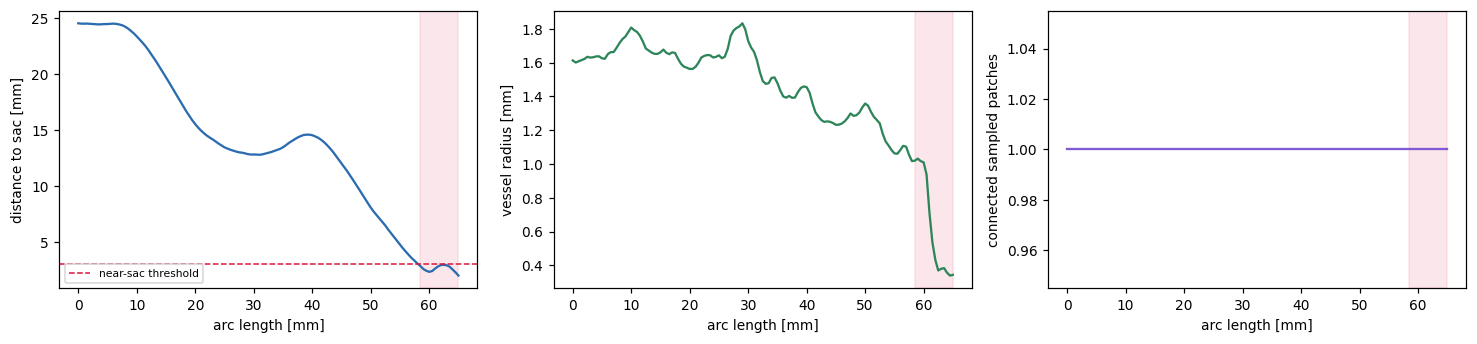

In [6]:
def _count_face_patches(face_ids):
    if len(face_ids) == 0: return 0
    parent = np.arange(len(face_ids))
    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]; a = parent[a]
        return a
    def union(a, b):
        a, b = find(a), find(b)
        if a != b: parent[b] = a
    owners = {}
    for local, face_id in enumerate(face_ids):
        for vertex in TRI[face_id]:
            if int(vertex) in owners: union(local, owners[int(vertex)])
            else: owners[int(vertex)] = local
    return len({find(i) for i in range(len(face_ids))})

def sample_fields(xyz, rad, arc):
    tan = np.gradient(xyz, axis=0)
    tan /= np.linalg.norm(tan, axis=1, keepdims=True) + 1e-12
    rows = []
    source_names = ["TAWSS", "OSI", "TAWSSG", "Lambda2_average", "Mean_Curvature"]
    missing = [name for name in source_names if name not in FACE_FIELDS]
    if missing: raise KeyError(f"Required cell fields missing: {missing}")

    for i in range(len(xyz)):
        ball = np.asarray(face_tree.query_ball_point(xyz[i], SAMPLE_RADII * max(rad[i], 0.3)))
        if len(ball) < MIN_FACES_NODE: continue
        axial = np.abs((FACE_CENTER[ball] - xyz[i]) @ tan[i])
        near = ball[axial < SLAB_MM]
        if len(near) < MIN_FACES_NODE: continue
        weights = FACE_AREA[near]
        if not np.isfinite(weights).all() or weights.sum() <= 0: continue
        means = {name: float(np.average(FACE_FIELDS[name][near], weights=weights))
                 for name in source_names}
        rec = {"node": i, "x": xyz[i, 0], "y": xyz[i, 1], "z": xyz[i, 2],
               "arclen": arc[i], "radius": rad[i], "n_faces": len(near),
               "sample_area": float(weights.sum()), "n_patches": _count_face_patches(near),
               **means}
        rec["WSSG_magnitude"] = abs(rec["TAWSSG"])
        rec["Vortex_strength"] = max(-rec["Lambda2_average"], 0.0)
        rec["Curvature_magnitude"] = abs(rec["Mean_Curvature"])
        rows.append(rec)
    return pd.DataFrame(rows).dropna().reset_index(drop=True)

BB = sample_fields(BXYZ, BRAD, BARC)
BB["dist_to_sac"] = sac_tree.query(BB[["x", "y", "z"]].values)[0]
near_sac_nodes = BB[BB.dist_to_sac <= NEAR_SAC_MM]
if len(near_sac_nodes):
    SAC_LO, SAC_HI = near_sac_nodes.arclen.min(), near_sac_nodes.arclen.max()
    print(f"near-sac centerline segment: {SAC_LO:.1f}-{SAC_HI:.1f} mm "
          f"({len(near_sac_nodes)} nodes within {NEAR_SAC_MM:g} mm of sac surface)")
else:
    SAC_LO = SAC_HI = None
    print("no centerline nodes fall within the near-sac threshold")

i_adjacent = int(BB.dist_to_sac.idxmin())
print(f"closest centerline point to sac: {BB.dist_to_sac[i_adjacent]:.2f} mm at "
      f"arc length {BB.arclen[i_adjacent]:.1f} mm")
print(f"sampled faces/node: median {BB.n_faces.median():.0f}; "
      f"nodes with >1 connected patch: {(BB.n_patches > 1).sum()}/{len(BB)}")

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.2))
ax[0].plot(BB.arclen, BB.dist_to_sac, color="#2b6cb0")
ax[0].axhline(NEAR_SAC_MM, ls="--", c="crimson", lw=1, label="near-sac threshold")
ax[0].set_ylabel("distance to sac [mm]"); ax[0].legend(fontsize=7)
ax[1].plot(BB.arclen, BB.radius, color="#2f855a"); ax[1].set_ylabel("vessel radius [mm]")
ax[2].step(BB.arclen, BB.n_patches, where="mid", color="#805ad5")
ax[2].set_ylabel("connected sampled patches")
for a in ax:
    if SAC_LO is not None: a.axvspan(SAC_LO, SAC_HI, color="crimson", alpha=.10)
    a.set_xlabel("arc length [mm]")
plt.tight_layout(); plt.show()


## 6. Channel complementarity and sampling audit

Channel selection is based on distinct physical semantics. Correlation with global x/y/z is
not used as a pass/fail rule because it changes under rotation and does not test nonlinear
spatial structure. The correlation matrix below is descriptive only: it identifies possible
redundancy among the selected channels.


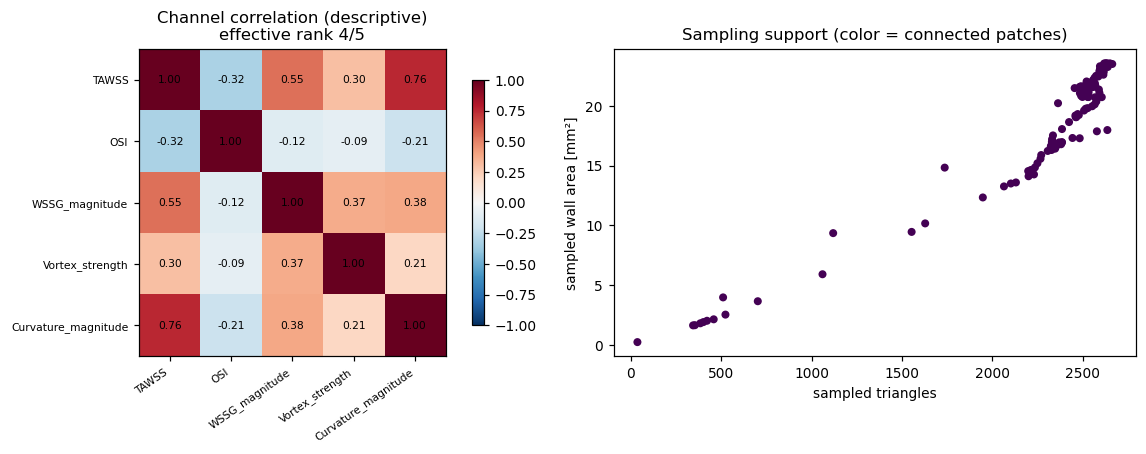

In [7]:
Cmat = BB[CH_USE].to_numpy(dtype=float)
Rch = np.corrcoef(Cmat.T)
Z = (Cmat - Cmat.mean(0)) / (Cmat.std(0) + 1e-12)
ev = np.linalg.svd(Z, compute_uv=False) ** 2; ev /= ev.sum()
r95 = int(np.searchsorted(np.cumsum(ev), 0.95) + 1)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
im = ax[0].imshow(Rch, cmap="RdBu_r", vmin=-1, vmax=1)
ax[0].set_xticks(range(len(CH_USE))); ax[0].set_yticks(range(len(CH_USE)))
ax[0].set_xticklabels(CH_USE, rotation=35, ha="right", fontsize=7)
ax[0].set_yticklabels(CH_USE, fontsize=7)
for i in range(len(CH_USE)):
    for j in range(len(CH_USE)):
        ax[0].text(j, i, f"{Rch[i,j]:.2f}", ha="center", va="center", fontsize=7)
ax[0].set_title(f"Channel correlation (descriptive)\neffective rank {r95}/{len(CH_USE)}")
plt.colorbar(im, ax=ax[0], shrink=.8)

ax[1].scatter(BB.n_faces, BB.sample_area, c=BB.n_patches, cmap="viridis", s=18)
ax[1].set_xlabel("sampled triangles"); ax[1].set_ylabel("sampled wall area [mm²]")
ax[1].set_title("Sampling support (color = connected patches)")
plt.tight_layout(); plt.show()


## 7. Does the backbone fold?

Folding means the path returns near its own past: two nodes close in space but far apart
along the arc. Without it, spatial position is a monotone function of arc length, the
backbone could be straightened without loss, and the glyph reduces to parallel line plots.

The test radius is set by the vessel calibre. Contacts appearing only at radii much larger
than the lumen are neighbouring branches passing nearby, **not** the path doubling back.

In [8]:
XYZ = BB[["x", "y", "z"]].values
tree_bb = cKDTree(XYZ)
arc = BB.arclen.values
mean_r = BB.radius.mean()

rows = []
for R in [1.0, 2.0, 3.0, 5.0]:
    pr = tree_bb.query_pairs(R, output_type="ndarray")
    n_far = int((np.abs(arc[pr[:, 0]] - arc[pr[:, 1]]) > FOLD_ARC_SEP).sum()) if len(pr) else 0
    rows.append(dict(radius_mm=R, radii_of_vessel=round(R / mean_r, 1),
                     pairs=len(pr), self_contacts=n_far))
FOLD = pd.DataFrame(rows)
display(FOLD)

near = FOLD[FOLD.radius_mm <= 3.0].self_contacts.max()
FOLDS = bool(near >= 5)
print(f"mean vessel radius: {mean_r:.2f} mm")
print(f"self-contacts by radius: {list(FOLD.self_contacts)}")
if FOLDS:
    print("\n>>> BACKBONE FOLDS.")
else:
    print("\n>>> BACKBONE DOES NOT FOLD (within this segment).")
    print("    Close pairs are also close along the path: the artery curves but does not")
    print("    double back. The 'spatial adjacency != sequence adjacency' claim is NOT")
    print("    demonstrated here -- state this explicitly.")
    if FOLD.self_contacts.max() > 0:
        print("    Contacts at the largest radius exceed the lumen calibre: that is")
        print("    proximity of neighbouring vessel, not folding.")

,radius_mm,radii_of_vessel,pairs,self_contacts
0,1.0,0.7,259,0
1,2.0,1.4,514,0
2,3.0,2.1,771,0
3,5.0,3.5,1287,0


mean vessel radius: 1.41 mm
self-contacts by radius: [0, 0, 0, 0]

>>> BACKBONE DOES NOT FOLD (within this segment).
    Close pairs are also close along the path: the artery curves but does not
    double back. The 'spatial adjacency != sequence adjacency' claim is NOT
    demonstrated here -- state this explicitly.


## 8. Signals along the path

These linked line plots are the quantitative baseline. The shaded interval is the
**near-sac centerline segment**, not the aneurysm itself. The distal radius and sampling
diagnostics must be checked before attributing endpoint changes to aneurysm effects.


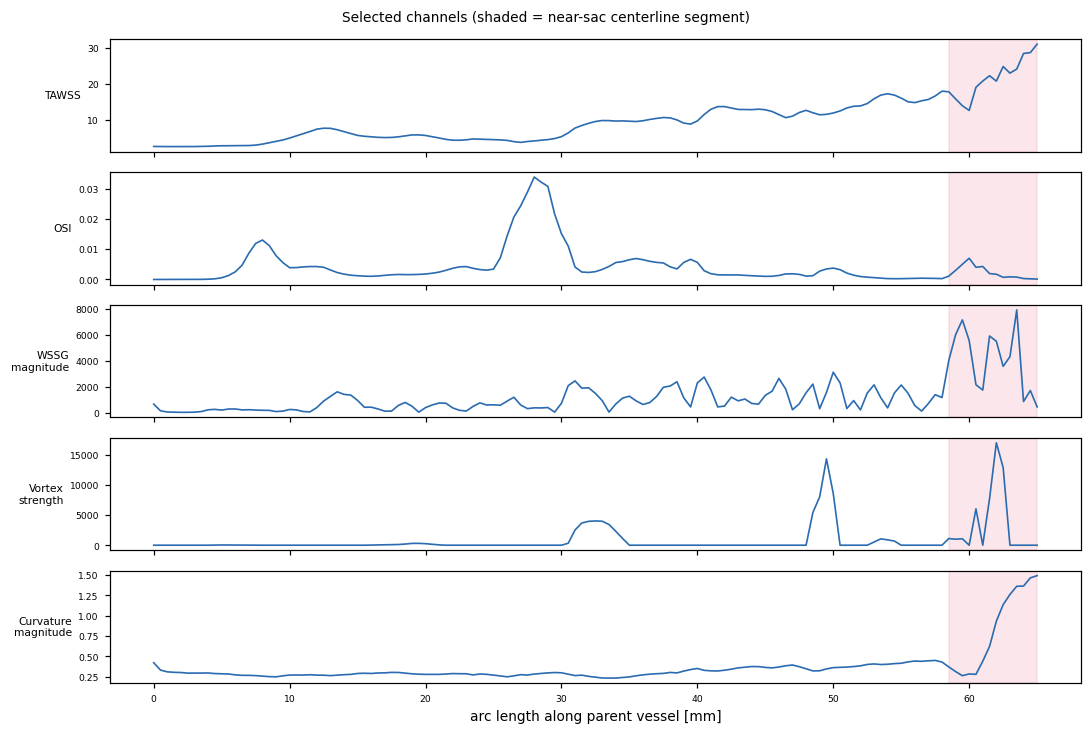

In [9]:
fig, axes = plt.subplots(len(CH_USE), 1, figsize=(10, 1.35 * len(CH_USE)), sharex=True)
for ax_, c in zip(axes, CH_USE):
    ax_.plot(BB.arclen, BB[c], lw=1.1, color="#2b6cb0")
    if SAC_LO is not None: ax_.axvspan(SAC_LO, SAC_HI, color="crimson", alpha=.10)
    ax_.set_ylabel(c.replace("_", "\n"), rotation=0, ha="right", va="center", fontsize=7)
    ax_.tick_params(labelsize=6)
axes[-1].set_xlabel("arc length along parent vessel [mm]")
fig.suptitle("Selected channels (shaded = near-sac centerline segment)", fontsize=9)
plt.tight_layout(); plt.show()


## 9. The glyph

One polygon is placed at each centerline node, with one fin per selected channel. All five
channels are non-negative and rank-normalised to handle heavy tails. Normalisation ranks
strictly positive values only, so a zero vortex signature remains exactly zero rather than
receiving the average rank of tied zeros.


glyph vertices (5): ['TAWSS', 'OSI', 'WSSG_magnitude', 'Vortex_strength', 'Curvature_magnitude']
zero vortex nodes remain zero: True


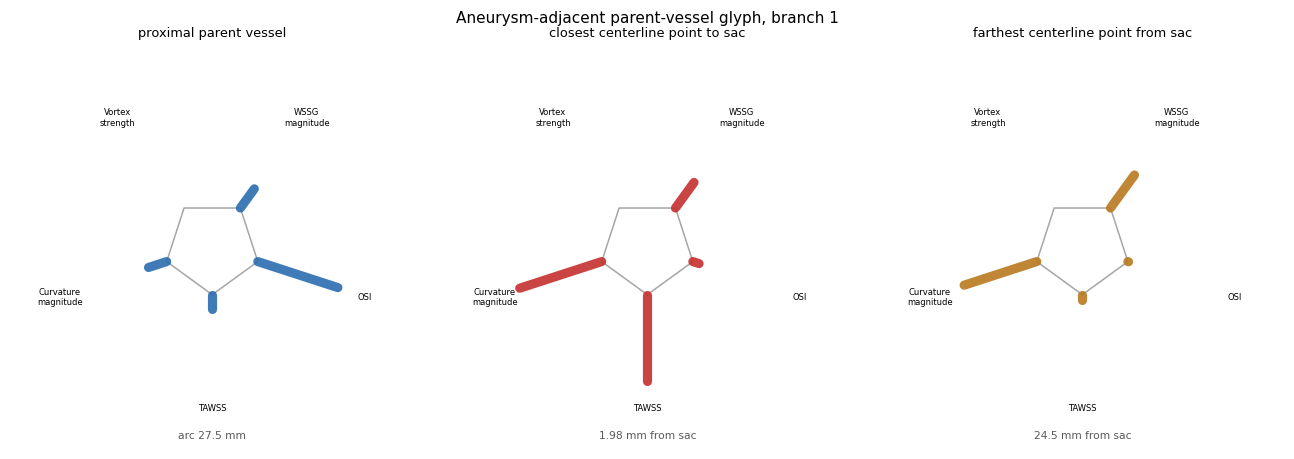

In [10]:
def normalize_nonnegative(raw):
    out = np.zeros_like(raw, dtype=float)
    for j in range(raw.shape[1]):
        positive = np.isfinite(raw[:, j]) & (raw[:, j] > 0)
        if positive.any(): out[positive, j] = rankdata(raw[positive, j]) / positive.sum()
    return out

RAWV = BB[CH_USE].to_numpy(dtype=float)
RN = normalize_nonnegative(RAWV)
print(f"glyph vertices ({len(CH_USE)}): {CH_USE}")
print(f"zero vortex nodes remain zero: {(RN[BB.Vortex_strength.eq(0), CH_USE.index('Vortex_strength')] == 0).all()}")

def draw_glyph(ax, vals, title, color, sub=""):
    n = len(vals); ang = np.linspace(0, 2*np.pi, n, endpoint=False) - np.pi/2
    sx, sy = np.cos(ang), np.sin(ang)
    ax.plot(np.r_[sx, sx[0]], np.r_[sy, sy[0]], color="0.65", lw=1)
    for a_, v, nm in zip(ang, vals, CH_USE):
        r = 1 + 1.8*np.clip(v, 0, 1)
        ax.plot([np.cos(a_), r*np.cos(a_)], [np.sin(a_), r*np.sin(a_)],
                color=color, lw=6, solid_capstyle="round", alpha=.9)
        ax.text(3.35*np.cos(a_), 3.35*np.sin(a_), nm.replace("_", "\n"),
                ha="center", va="center", fontsize=5.5)
    ax.set(xlim=(-4.2,4.2), ylim=(-4.2,4.2)); ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(title, fontsize=8.5)
    if sub: ax.text(0, -4.0, sub, ha="center", fontsize=7, color="0.35")

prox = BB[BB.arclen < BB.arclen.iloc[i_adjacent] - 10]
i_prox = int(prox.index[len(prox)//2]) if len(prox) else 0
i_far = int(BB.dist_to_sac.idxmax())
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
draw_glyph(axes[0], RN[i_prox], "proximal parent vessel", "#2b6cb0", f"arc {BB.arclen[i_prox]:.1f} mm")
draw_glyph(axes[1], RN[i_adjacent], "closest centerline point to sac", "#c53030",
           f"{BB.dist_to_sac[i_adjacent]:.2f} mm from sac")
draw_glyph(axes[2], RN[i_far], "farthest centerline point from sac", "#b7791f",
           f"{BB.dist_to_sac[i_far]:.1f} mm from sac")
fig.suptitle(f"Aneurysm-adjacent parent-vessel glyph, branch {BRANCH}", fontsize=10)
plt.tight_layout(); plt.show()


## 10. Vessel context in 3D

The sac surface is red and the selected parent-vessel centerline is blue. The white marker
is the **closest centerline point to the sac**, not the anatomical aneurysm neck. A control
branch is shown only as geometric context; no effect-size claim is made without a matched,
uncertainty-aware comparison.


In [11]:
import plotly.graph_objects as go

sac_tri = SAC[TRI].all(axis=1)
fig = go.Figure()
fig.add_trace(go.Mesh3d(x=WALL[:,0], y=WALL[:,1], z=WALL[:,2],
                        i=TRI[~sac_tri,0], j=TRI[~sac_tri,1], k=TRI[~sac_tri,2],
                        color="lightgray", opacity=.25, name="vessel wall"))
fig.add_trace(go.Mesh3d(x=WALL[:,0], y=WALL[:,1], z=WALL[:,2],
                        i=TRI[sac_tri,0], j=TRI[sac_tri,1], k=TRI[sac_tri,2],
                        color="crimson", opacity=.55, name="aneurysm sac"))
fig.add_trace(go.Scatter3d(x=BB.x, y=BB.y, z=BB.z, mode="lines",
                           line=dict(color="#1a365d", width=6), name=f"parent-vessel branch {BRANCH}"))
fig.add_trace(go.Scatter3d(x=[BB.x[i_adjacent]], y=[BB.y[i_adjacent]], z=[BB.z[i_adjacent]],
                           mode="markers+text", marker=dict(size=7, color="white", symbol="diamond"),
                           text=["closest centerline point to sac"], textposition="top center",
                           name="closest centerline point to sac"))
if CONTROL is not None:
    cx, _, _ = build_backbone(CONTROL)
    fig.add_trace(go.Scatter3d(x=cx[:,0], y=cx[:,1], z=cx[:,2], mode="lines",
                               line=dict(color="#2f855a", width=4, dash="dot"),
                               name=f"control branch {CONTROL} (geometry only)"))
fig.update_layout(height=750, title="Aneurysm sac and adjacent parent-vessel centerline",
                  scene=dict(aspectmode="data", xaxis_title="x [mm]", yaxis_title="y [mm]", zaxis_title="z [mm]"))
fig.show()


  trimmed 575 -> 575 points (100% kept)


In [12]:
# Export the aneurysm-adjacent parent-vessel glyph and surface context.
import json
from pathlib import Path

TARGET_BRANCH = 1
_repo_public = Path("Frontend/public")
if not _repo_public.exists(): _repo_public = Path("../Frontend/public")
_repo_public.mkdir(parents=True, exist_ok=True)
branch_glyph_path = _repo_public / "aneurysm_glyph.json"
aneurysm_path = _repo_public / "aneurysm_geometry.json"

def _make_branch_dataframe(branch):
    if int(BRANCH) == int(branch): return BB.copy()
    xyz, rad, arc = build_backbone(branch)
    out = sample_fields(xyz, rad, arc)
    out["dist_to_sac"] = sac_tree.query(out[["x","y","z"]].values)[0]
    return out

def _round3(point): return [round(float(v), 4) for v in point]

BB_EXPORT = _make_branch_dataframe(TARGET_BRANCH)
RN_EXPORT = normalize_nonnegative(BB_EXPORT[CH_USE].to_numpy(dtype=float))
points = []
for row, vals in zip(BB_EXPORT.itertuples(index=False), RN_EXPORT):
    points.append({
        "x": round(float(row.x),4), "y": round(float(row.y),4), "z": round(float(row.z),4),
        "values": [round(float(v),4) for v in vals],
        "attributes": {"node": int(row.node), "arclen": round(float(row.arclen),4),
            "radius": round(float(row.radius),4), "dist_to_sac": round(float(row.dist_to_sac),4),
            "n_faces": int(row.n_faces), "sample_area": round(float(row.sample_area),6),
            "n_patches": int(row.n_patches),
            "raw_values": {c: round(float(getattr(row,c)),6) for c in CH_USE}}
    })

near_export = BB_EXPORT[BB_EXPORT.dist_to_sac <= NEAR_SAC_MM]
adjacent_idx = int(BB_EXPORT.dist_to_sac.idxmin())
adjacent = BB_EXPORT.loc[adjacent_idx]
branch_payload = {
    "meta": {
        "caseType": "aneurysm-adjacent-parent-vessel", "title": "Aneurysm-adjacent parent-vessel hemodynamics",
        "description": "Area-weighted summaries of wall-derived CFD fields placed along parent-vessel centerline branch 1.",
        "interpretation": "Local cross-section-associated wall summaries; not centerline flow measurements.",
        "limitation": "The path does not enter the aneurysm sac and does not represent dome or sac-interior hemodynamics.",
        "unit": "coordinates/radius/arclen in mm; glyph values positive-only rank-normalized to [0,1]",
        "source": {"surface": SURF_PATH, "centerline": CL_PATH}, "branch": TARGET_BRANCH,
        "nObjects": 1, "nPointsPerObject": len(points), "resampleMm": RESAMPLE_MM,
        "sampleRadii": SAMPLE_RADII, "slabMm": SLAB_MM, "areaWeighted": True,
        "nearSacThresholdMm": NEAR_SAC_MM,
        "nearSacArcRangeMm": ([round(float(near_export.arclen.min()),4), round(float(near_export.arclen.max()),4)]
                              if len(near_export) else None),
        "coordinates": "original VTP coordinate system"
    },
    "channels": CH_USE,
    "objects": [{"objectId": TARGET_BRANCH, "label": "aneurysm-adjacent-parent-vessel", "points": points}],
}

sac_mask_tri = SAC[TRI].all(axis=1)
def _compact_mesh(triangles):
    vertex_ids = np.unique(triangles.reshape(-1)); old_to_new = {int(v):i for i,v in enumerate(vertex_ids)}
    return vertex_ids, WALL[vertex_ids], [[old_to_new[int(v)] for v in face] for face in triangles]
sac_ids, sac_points, sac_faces = _compact_mesh(TRI[sac_mask_tri])
vessel_ids, vessel_points, vessel_faces = _compact_mesh(TRI[~sac_mask_tri])
sac_center = sac_points.mean(0); sac_min=sac_points.min(0); sac_max=sac_points.max(0)
sac_dist=np.linalg.norm(sac_points-sac_center,axis=1)
vessel_center=vessel_points.mean(0); vessel_min=vessel_points.min(0); vessel_max=vessel_points.max(0)

aneurysm_payload = {
    "meta": {"title": "Aneurysm sac surface and parent-vessel context",
        "description": "Sac geometry uses wall triangles whose vertices satisfy DistanceToNeck < 0. The centerline marker is proximity-based, not an anatomical neck.",
        "unit": "millimeters", "source": {"surface": SURF_PATH, "centerline": CL_PATH},
        "branch": TARGET_BRANCH, "meshKind": "surface-triangles",
        "sacCriterion": "DistanceToNeck < 0 at all three triangle vertices"},
    "center": {"x":round(float(sac_center[0]),4),"y":round(float(sac_center[1]),4),"z":round(float(sac_center[2]),4)},
    "size": {"bboxMin":_round3(sac_min),"bboxMax":_round3(sac_max),"extent":_round3(sac_max-sac_min),
             "maxRadiusFromCenter":round(float(sac_dist.max()),4),"meanRadiusFromCenter":round(float(sac_dist.mean()),4),
             "equivalentDiameterApprox":round(float(2*sac_dist.max()),4)},
    "closestCenterlinePoint": {"x":round(float(adjacent.x),4),"y":round(float(adjacent.y),4),"z":round(float(adjacent.z),4),
        "node":int(adjacent.node),"arclen":round(float(adjacent.arclen),4),"dist_to_sac":round(float(adjacent.dist_to_sac),4),
        "label":"Closest centerline point to sac (not anatomical neck)"},
    "mesh": {"vertices":[_round3(p) for p in sac_points],"faces":sac_faces,
             "originalVertexIds":[int(v) for v in sac_ids],"distanceToNeck":[round(float(v),6) for v in DN[sac_ids]]},
    "vessel": {"description":"Non-sac vessel wall surface; sac triangles are stored separately.",
        "center":{"x":round(float(vessel_center[0]),4),"y":round(float(vessel_center[1]),4),"z":round(float(vessel_center[2]),4)},
        "size":{"bboxMin":_round3(vessel_min),"bboxMax":_round3(vessel_max),"extent":_round3(vessel_max-vessel_min)},
        "mesh":{"vertices":[_round3(p) for p in vessel_points],"faces":vessel_faces,
                "originalVertexIds":[int(v) for v in vessel_ids],"distanceToNeck":[round(float(v),6) for v in DN[vessel_ids]]},
        "fields":sorted(FIELDS.keys()),"distanceToNeckRange":[round(float(DN.min()),6),round(float(DN.max()),6)],
        "nWallPoints":int(len(WALL)),"nWallFaces":int(len(TRI))},
    "nSacWallPoints": int(SAC.sum())
}

with open(branch_glyph_path,"w") as f: json.dump(branch_payload,f,indent=2)
with open(aneurysm_path,"w") as f: json.dump(aneurysm_payload,f,indent=2)
print(f"saved {branch_glyph_path} ({len(points)} points, {len(CH_USE)} channels)")
print(f"saved {aneurysm_path} ({len(sac_faces)} sac faces, {len(vessel_faces)} vessel faces)")


saved ../Frontend/public/aneurysm_glyph.json (131 points, 5 channels)
saved ../Frontend/public/aneurysm_geometry.json (4578 sac faces, 92220 vessel faces)
